In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Saving ai4i2020.csv to ai4i2020.csv
Dataset loaded successfully!
Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe(include="all").T)

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure           

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Target percentages:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


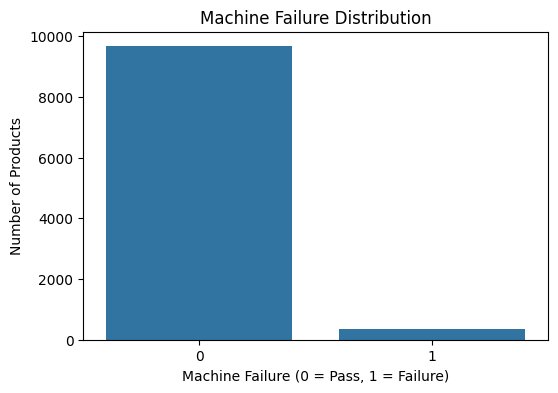

In [4]:
TARGET = "Machine failure"

print("Target distribution:")
print(df[TARGET].value_counts())

print("\nTarget percentages:")
print(df[TARGET].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = Pass, 1 = Failure)")
plt.ylabel("Number of Products")
plt.show()

In [5]:
# Remove identifiers and failure-mode columns.
# Failure-mode columns can reveal the target directly.

DROP_COLUMNS = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = df.drop(columns=[TARGET] + DROP_COLUMNS, errors="ignore")
y = df[TARGET].astype(int)

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Feature columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Feature shape: (10000, 6)
Target shape: (10000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 8000
Testing samples: 2000

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [7]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Categorical features: ['Type']


In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Models defined successfully!")

Models defined successfully!


In [9]:
results = []
trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    results.append(metrics)
    trained_models[model_name] = pipeline

    print(f"\n{'=' * 50}")
    print(model_name)
    print(f"{'=' * 50}")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Pass", "Failure"],
        zero_division=0
    ))

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


Logistic Regression
              precision    recall  f1-score   support

        Pass       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


Decision Tree
              precision    recall  f1-score   support

        Pass       0.99      0.96      0.98      1932
     Failure       0.42      0.84      0.56        68

    accuracy                           0.95      2000
   macro avg       0.71      0.90      0.77      2000
weighted avg       0.97      0.95      0.96      2000


Random Forest
              precision    recall  f1-score   support

        Pass       0.99      0.99      0.99      1932
     Failure       0.73      0.59      0.65        68

    accuracy                           0.98      2000
   macro avg       0.86      0.79      0.82      2000
weighted avg       0.98

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9070
1,Decision Tree,0.9550,0.4191,0.8382,0.5588,0.9090
2,Random Forest,0.9785,0.7273,0.5882,0.6504,0.9723


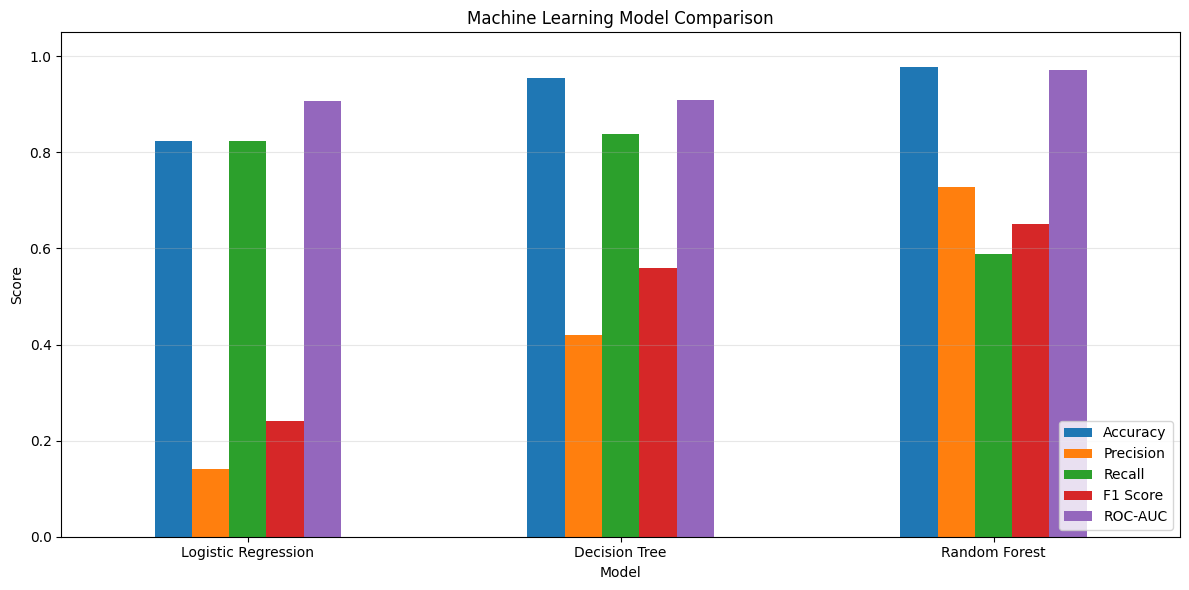

In [10]:
results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
results_sorted = results_df.sort_values(
    by=["Recall", "F1 Score", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

best_model_name = results_sorted.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)

display(
    results_sorted.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Selected model: Decision Tree


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.9550,0.4191,0.8382,0.5588,0.9090
1,Logistic Regression,0.8245,0.1418,0.8235,0.2419,0.9070
2,Random Forest,0.9785,0.7273,0.5882,0.6504,0.9723


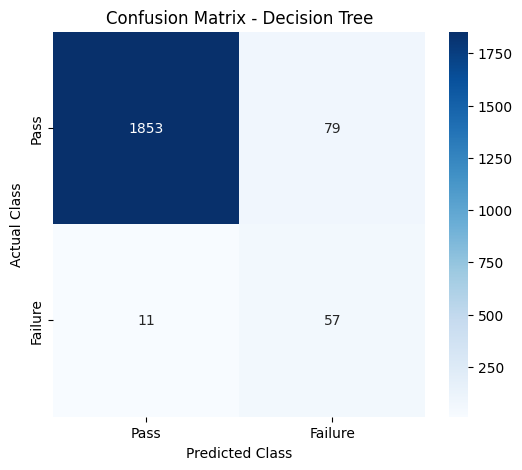

Confusion Matrix:
[[1853   79]
 [  11   57]]


In [12]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pass", "Failure"],
    yticklabels=["Pass", "Failure"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

print("Confusion Matrix:")
print(cm)

<Figure size 700x500 with 0 Axes>

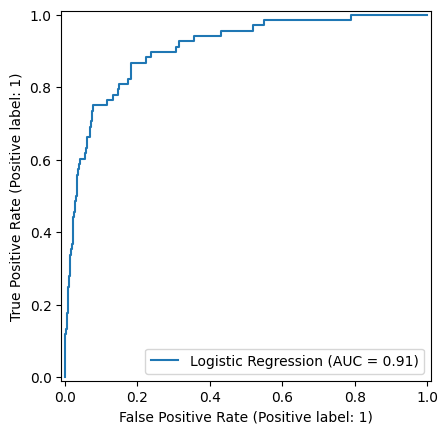

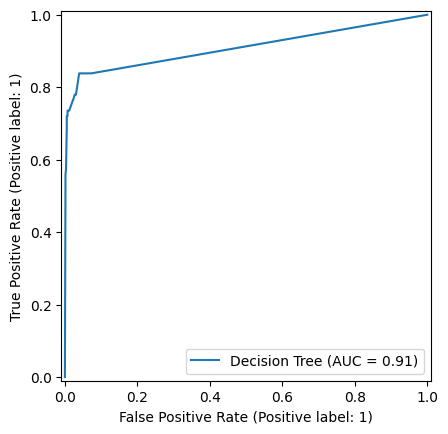

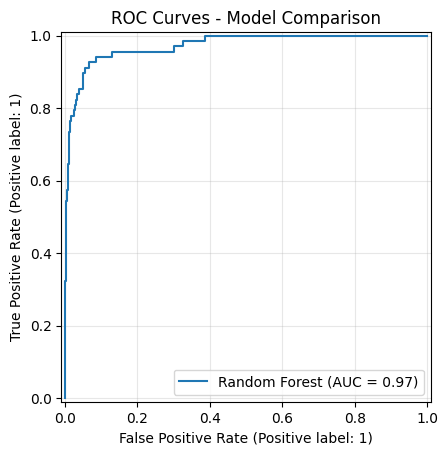

In [13]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 5))

for model_name, pipeline in trained_models.items():
    RocCurveDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        name=model_name
    )

plt.title("ROC Curves - Model Comparison")
plt.grid(alpha=0.3)
plt.show()

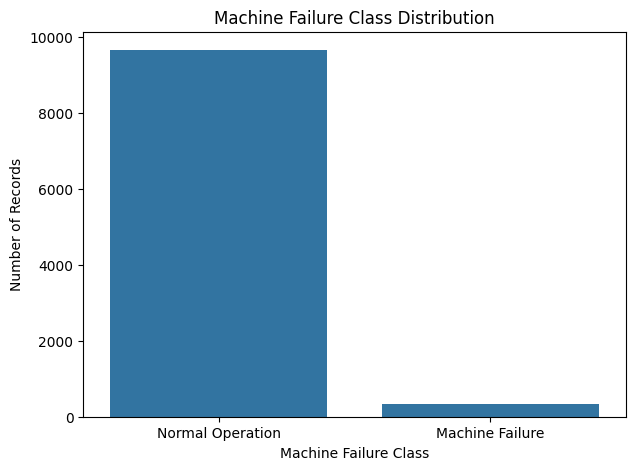

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Machine Failure Class Distribution")
plt.xlabel("Machine Failure Class")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["Normal Operation", "Machine Failure"])

plt.show()

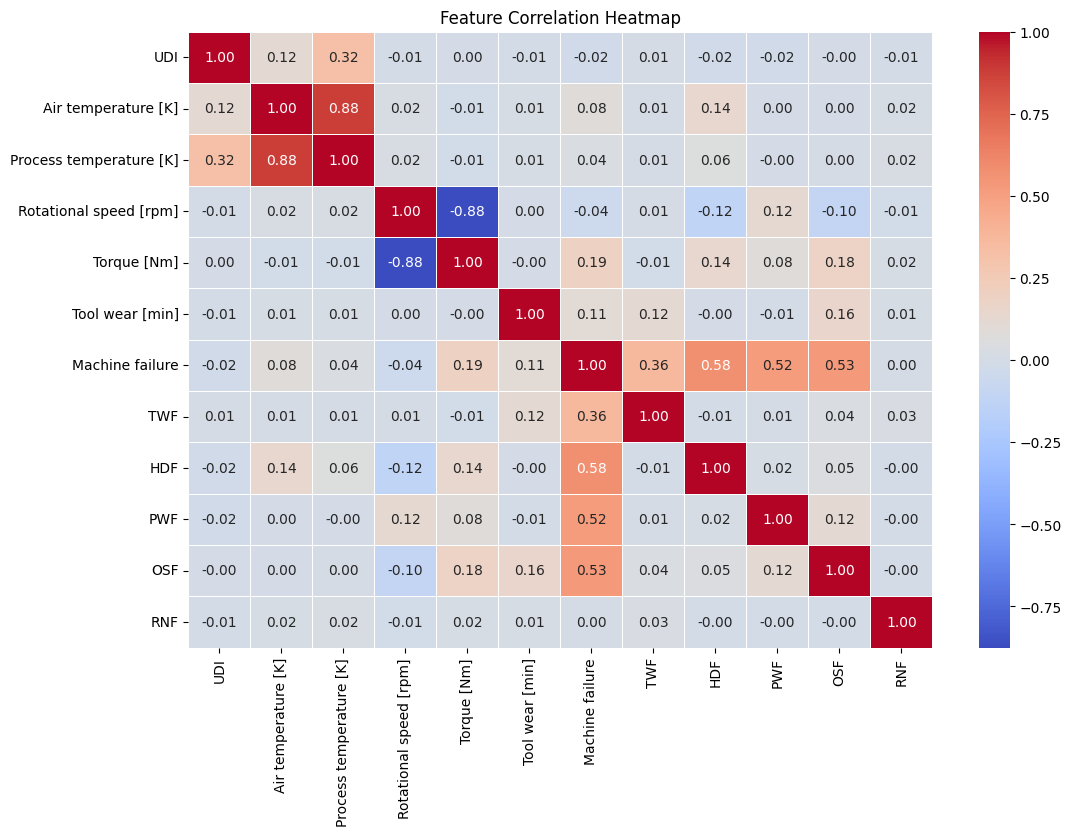

In [23]:
plt.figure(figsize=(12, 8))

numeric_data = df.select_dtypes(include="number")

correlation_matrix = numeric_data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

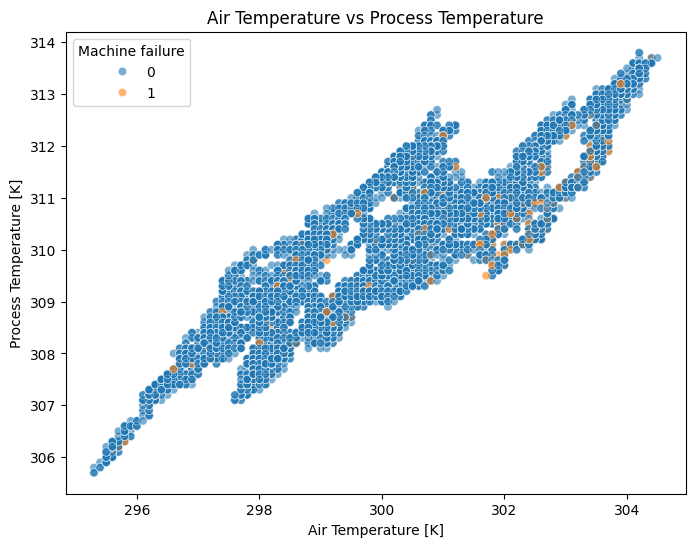

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue=TARGET,
    alpha=0.6
)

plt.title("Air Temperature vs Process Temperature")
plt.xlabel("Air Temperature [K]")
plt.ylabel("Process Temperature [K]")
plt.legend(title=TARGET)

plt.show()

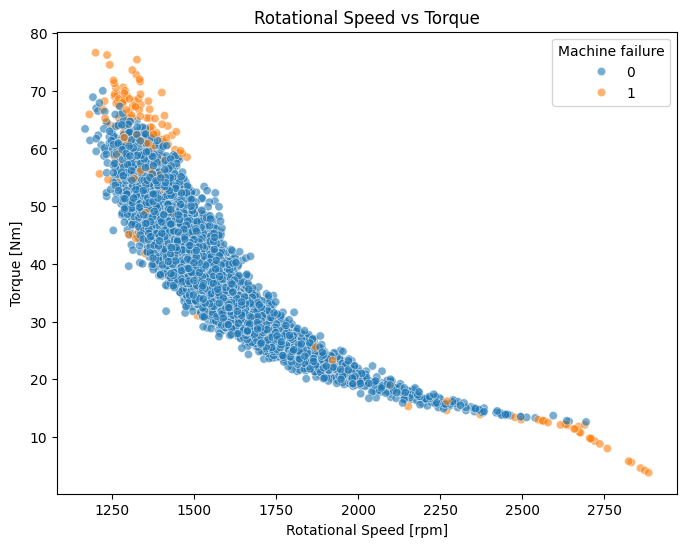

In [25]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue=TARGET,
    alpha=0.6
)

plt.title("Rotational Speed vs Torque")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.legend(title=TARGET)

plt.show()

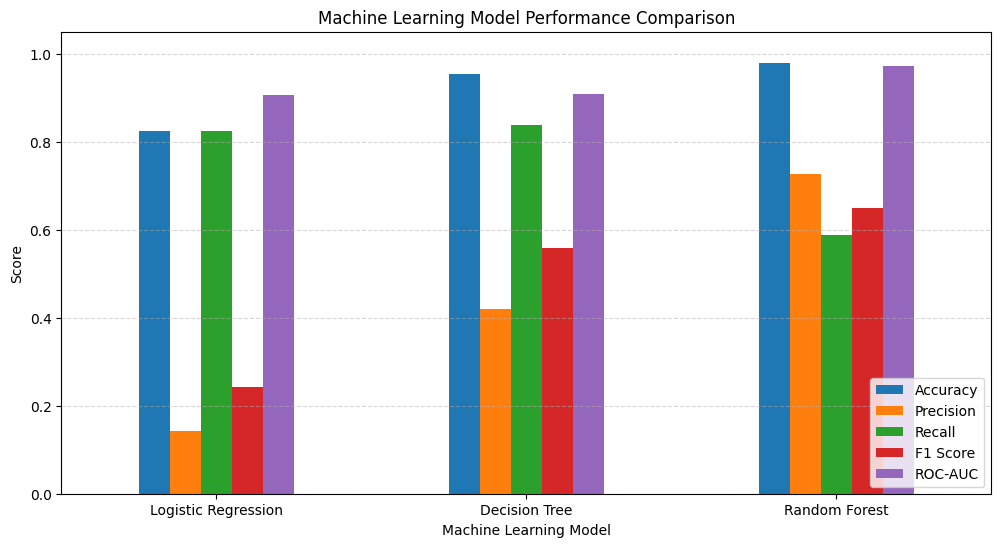

In [27]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_plot = results_df.set_index("Model")[metrics_to_plot]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [14]:
MODEL_FILE = "manufacturing_quality_model.joblib"

joblib.dump(best_model, MODEL_FILE)

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Trained model saved:", MODEL_FILE)
print("Model comparison saved: model_comparison.csv")

Trained model saved: manufacturing_quality_model.joblib
Model comparison saved: model_comparison.csv


In [15]:
sample = pd.DataFrame([{
    "Type": "M",
    "Air temperature [K]": 298.1,
    "Process temperature [K]": 308.6,
    "Rotational speed [rpm]": 1551,
    "Torque [Nm]": 42.8,
    "Tool wear [min]": 0
}])

prediction = int(best_model.predict(sample)[0])
failure_probability = float(
    best_model.predict_proba(sample)[0, 1]
)

print("Predicted class:", prediction)
print(
    "Quality result:",
    "FAILURE" if prediction == 1 else "PASS"
)
print(
    f"Failure probability: {failure_probability:.2%}"
)

Predicted class: 0
Quality result: PASS
Failure probability: 0.00%


In [18]:
from google.colab import files

files.download("manufacturing_quality_model.joblib")
files.download("model_comparison.csv")
print("Files download successfully ")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files download successfully 
